<a href="https://colab.research.google.com/github/ANANYA-JPG/data-mining-and-ML/blob/main/Ocean_Deoxygenation_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--2026-05-14 11:43:04--  https://psl.noaa.gov/thredds/ncss/grid/Datasets/noaa.oisst.v2.highres/sst.mon.mean.nc?var=sst&north=45&south=20&west=220&east=250&time_start=2000-01-01T00:00:00Z&time_end=2025-12-01T00:00:00Z&accept=netcdf4
Resolving psl.noaa.gov (psl.noaa.gov)... 140.172.38.12
Connecting to psl.noaa.gov (psl.noaa.gov)|140.172.38.12|:443... connected.
HTTP request sent, awaiting response... 200 
Length: 7701572 (7.3M) [application/x-netcdf]
Saving to: ‘small_oisst.nc’

small_oisst.nc      100%[===================>]   7.34M  1.68MB/s    in 6.5s    

2026-05-14 11:43:11 (1.13 MB/s) - ‘small_oisst.nc’ saved [7701572/7701572]

Download complete.
<xarray.Dataset> Size: 15MB
Dimensions:  (time: 312, lat: 101, lon: 121)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2000-01-01 2000-02-01 ... 2025-12-01
  * lat      (lat) float32 404B 20.12 20.38 20.62 20.88 ... 44.62 44.88 45.12
  * lon      (lon) float32 484B 220.1 220.4 220.6 220.9 ... 249.6 249.9 250.1
Data variables:
    sst 

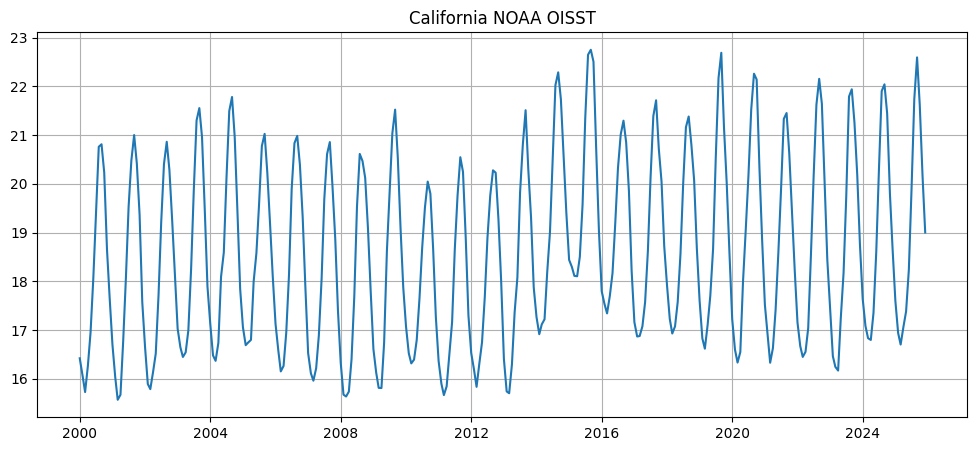

Saved oisst_monthly.csv
Upload CalCOFI bottle.csv


In [ ]:
# ============================================================
# STABLE NOAA DOWNLOAD (SHORTER TIMERANGE)
# ============================================================

!pip install xarray netCDF4 -q

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

URL = (
    "https://psl.noaa.gov/thredds/ncss/grid/"
    "Datasets/noaa.oisst.v2.highres/sst.mon.mean.nc"
    "?var=sst"
    "&north=45"
    "&south=20"
    "&west=220"
    "&east=250"
    "&time_start=2000-01-01T00:00:00Z"
    "&time_end=2025-12-01T00:00:00Z"
    "&accept=netcdf4"
)

print("Downloading snipped NOAA subset.")

!wget --tries=20 --timeout=60 -O small_oisst.nc "$URL"

print("Download complete.")

ds = xr.open_dataset("small_oisst.nc")

print(ds)

sst = ds["sst"]

# Clean
sst = sst.where((sst > -3) & (sst < 45), np.nan)

lat_name = "lat"
lon_name = "lon"

# Regional average
oisst = (
    sst.mean(
        dim=[lat_name, lon_name],
        skipna=True
    )
    .compute()
)

# Convert to dataframe
oisst_df = (
    oisst.to_dataframe(name="OISST")
    .reset_index()
)

oisst_df["Date"] = (
    pd.to_datetime(oisst_df["time"])
    .dt.to_period("M")
    .dt.to_timestamp()
)

oisst_df = (
    oisst_df
    .groupby("Date")["OISST"]
    .mean()
    .to_frame()
)

print(oisst_df.head())

# Plot
plt.figure(figsize=(12,5))
plt.plot(oisst_df.index, oisst_df["OISST"])
plt.title("California NOAA OISST")
plt.grid(True)
plt.show()

# Save final CSV
oisst_df.to_csv("oisst_monthly.csv")

print("Saved oisst_monthly.csv")

# Upload CalCOFI bottle.csv

print("Upload CalCOFI bottle.csv")
uploaded_bottle = files.upload()

bottle_name = list(uploaded_bottle.keys())[0]
print("Bottle file uploaded:", bottle_name)

# Read only useful columns to reduce processing time
needed_cols = [
    "Cst_Cnt",
    "Depth_ID",
    "Depthm",
    "T_degC",
    "Salnty",
    "O2ml_L",
    "Oxy_µmol/Kg",
    "R_O2",
    "O2Sat",
    "NO3uM",
    "PO4uM",
    "SiO3uM",
    "ChlorA"
]

header = pd.read_csv(io.BytesIO(uploaded_bottle[bottle_name]), nrows=0)
available_cols = header.columns.tolist()
use_cols = [c for c in needed_cols if c in available_cols]

cal = pd.read_csv(
    io.BytesIO(uploaded_bottle[bottle_name]),
    usecols=use_cols,
    low_memory=False
)

print("Loaded CalCOFI bottle shape:", cal.shape)
print("Columns loaded:", cal.columns.tolist())

# Parse date from Depth_ID
# Depth_ID format:

parts = cal["Depth_ID"].astype(str).str.split("-", expand=True)

cal["YYMMShip"] = parts[1]
cal["YY"] = pd.to_numeric(cal["YYMMShip"].str[0:2], errors="coerce")
cal["MM"] = pd.to_numeric(cal["YYMMShip"].str[2:4], errors="coerce")

cal = cal.dropna(subset=["YY", "MM"])
cal["YY"] = cal["YY"].astype(int)
cal["MM"] = cal["MM"].astype(int)

current_yy = pd.Timestamp.now().year % 100
cal["Year"] = np.where(cal["YY"] <= current_yy, 2000 + cal["YY"], 1900 + cal["YY"])
cal["Month"] = cal["MM"]

cal = cal[(cal["Month"] >= 1) & (cal["Month"] <= 12)]

cal["Date"] = pd.to_datetime(
    dict(year=cal["Year"], month=cal["Month"], day=1),
    errors="coerce"
)

cal = cal.dropna(subset=["Date"])

print("CalCOFI date range:", cal["Date"].min(), "to", cal["Date"].max())

# 3. Upload CalCOFI cast.csv for latitude/longitude

print("Optional: Upload cast.csv if you have it. If not, click Cancel.")
uploaded_cast = files.upload()

if len(uploaded_cast) > 0:
    cast_name = list(uploaded_cast.keys())[0]
    print("Cast file uploaded:", cast_name)

    cast_header = pd.read_csv(io.BytesIO(uploaded_cast[cast_name]), nrows=0)
    cast_cols = cast_header.columns.tolist()

    lat_candidates = [c for c in cast_cols if "lat" in c.lower()]
    lon_candidates = [c for c in cast_cols if "lon" in c.lower() or "long" in c.lower()]

    print("Latitude candidates:", lat_candidates)
    print("Longitude candidates:", lon_candidates)

    if "Cst_Cnt" in cast_cols and len(lat_candidates) > 0 and len(lon_candidates) > 0:
        lat_col = lat_candidates[0]
        lon_col = lon_candidates[0]

        cast = pd.read_csv(
            io.BytesIO(uploaded_cast[cast_name]),
            usecols=["Cst_Cnt", lat_col, lon_col],
            low_memory=False
        )

        cast = cast.rename(columns={
            lat_col: "Lat",
            lon_col: "Lon"
        })

        cal = cal.merge(cast, on="Cst_Cnt", how="left")
        print("Location added from cast.csv.")

    else:
        print("Could not identify location columns. Using California fallback.")
        cal["Lat"] = 34.0522
        cal["Lon"] = -118.2437

else:
    print("No cast.csv uploaded. Using California fallback location.")
    cal["Lat"] = 34.0522
    cal["Lon"] = -118.2437

# 4. Choose real oxygen column

oxygen_candidates = [c for c in ["Oxy_µmol/Kg", "O2ml_L", "R_O2"] if c in cal.columns]

if len(oxygen_candidates) == 0:
    raise ValueError("No real oxygen column found. Need Oxy_µmol/Kg, O2ml_L, or R_O2.")

oxygen_col = oxygen_candidates[0]
print("Using real oxygen column:", oxygen_col)

# 5. Aggregate CalCOFI monthly

agg_dict = {
    "T_degC": "mean",
    oxygen_col: "mean",
    "Lat": "mean",
    "Lon": "mean"
}

optional_features = ["Salnty", "Depthm", "O2Sat", "NO3uM", "PO4uM", "SiO3uM", "ChlorA"]

for col in optional_features:
    if col in cal.columns:
        agg_dict[col] = "mean"

cal_monthly = cal.groupby("Date").agg(agg_dict)

rename_dict = {
    "T_degC": "CalCOFISST",
    oxygen_col: "O2",
    "Salnty": "Salinity",
    "Depthm": "Depth",
    "O2Sat": "OxygenSaturation",
    "NO3uM": "Nitrate",
    "PO4uM": "Phosphate",
    "SiO3uM": "Silicate",
    "ChlorA": "Chlorophyll"
}

cal_monthly = cal_monthly.rename(columns=rename_dict)

print("Monthly CalCOFI shape:", cal_monthly.shape)
display(cal_monthly.head())

# 6. Upload NOAA OISST monthly file: sst.mon.mean.nc

print("Upload NOAA OISST file: sst.mon.mean.nc")
uploaded_oisst = files.upload()

oisst_name = list(uploaded_oisst.keys())[0]
print("OISST file uploaded:", oisst_name)

with open(oisst_name, "wb") as f:
    f.write(uploaded_oisst[oisst_name])

ds = xr.open_dataset(oisst_name)

print(ds)

# 7. Subset OISST to California / Eastern Pacific region

# NOAA OISST DIRECT REMOTE ACCESS

!pip install xarray netCDF4 pydap -q

import xarray as xr
import pandas as pd

# NOAA PSL OPeNDAP monthly OISST v2.1 URL
OISST_URL = "https://psl.noaa.gov/thredds/dodsC/Datasets/noaa.oisst.v2.highres/sst.mon.mean.nc"

# Open remote dataset without downloading full file
ds = xr.open_dataset(OISST_URL)

print(ds)

# Subset region to reduce processing time

oisst_region = ds.sel(
    lat=slice(20, 45),
    lon=slice(220, 250)
)

# restrict years to match CalCOFI after 1981
oisst_region = oisst_region.sel(
    time=slice("1981-09-01", "2025-12-31")
)

# Average over selected region
oisst_monthly = (
    oisst_region["sst"]
    .mean(dim=["lat", "lon"], skipna=True)
    .to_dataframe()
    .reset_index()
)

oisst_monthly["Date"] = (
    pd.to_datetime(oisst_monthly["time"])
    .dt.to_period("M")
    .dt.to_timestamp()
)

oisst_monthly = (
    oisst_monthly
    .groupby("Date")["sst"]
    .mean()
    .rename("OISST")
    .to_frame()
)

print("OISST monthly shape:", oisst_monthly.shape)
print("OISST date range:", oisst_monthly.index.min(), "to", oisst_monthly.index.max())
display(oisst_monthly.head())

# 9. Add ML target: next-month deoxygenation event

# Bottom 20% of real observed oxygen = low oxygen event
o2_threshold = merged["O2"].quantile(0.20)

merged["Deoxy_event"] = (merged["O2"] < o2_threshold).astype(int)
merged["Deoxy_next"] = merged["Deoxy_event"].shift(-1)

merged = merged.dropna(subset=["Deoxy_next"])
merged["Deoxy_next"] = merged["Deoxy_next"].astype(int)

print("O2 threshold:", o2_threshold)
print("Target distribution:")
print(merged["Deoxy_next"].value_counts())

# 10. Save final dataset

output_file = "merged_real_o2_oisst_dataset.csv"
merged.to_csv(output_file)

print("Saved:", output_file)
files.download(output_file)

In [ ]:
# Upload CalCOFI bottle.csv

print("Upload CalCOFI bottle.csv")
uploaded_bottle = files.upload()

bottle_name = list(uploaded_bottle.keys())[0]
print("Bottle file uploaded:", bottle_name)

# Read only useful columns to reduce processing time
needed_cols = [
    "Cst_Cnt",
    "Depth_ID",
    "Depthm",
    "T_degC",
    "Salnty",
    "O2ml_L",
    "Oxy_µmol/Kg",
    "R_O2",
    "O2Sat",
    "NO3uM",
    "PO4uM",
    "SiO3uM",
    "ChlorA"
]

header = pd.read_csv(io.BytesIO(uploaded_bottle[bottle_name]), nrows=0)
available_cols = header.columns.tolist()
use_cols = [c for c in needed_cols if c in available_cols]

cal = pd.read_csv(
    io.BytesIO(uploaded_bottle[bottle_name]),
    usecols=use_cols,
    low_memory=False
)

print("Loaded CalCOFI bottle shape:", cal.shape)
print("Columns loaded:", cal.columns.tolist())

# Parse date from Depth_ID

parts = cal["Depth_ID"].astype(str).str.split("-", expand=True)

cal["YYMMShip"] = parts[1]
cal["YY"] = pd.to_numeric(cal["YYMMShip"].str[0:2], errors="coerce")
cal["MM"] = pd.to_numeric(cal["YYMMShip"].str[2:4], errors="coerce")

cal = cal.dropna(subset=["YY", "MM"])
cal["YY"] = cal["YY"].astype(int)
cal["MM"] = cal["MM"].astype(int)

current_yy = pd.Timestamp.now().year % 100
cal["Year"] = np.where(cal["YY"] <= current_yy, 2000 + cal["YY"], 1900 + cal["YY"])
cal["Month"] = cal["MM"]

cal = cal[(cal["Month"] >= 1) & (cal["Month"] <= 12)]

cal["Date"] = pd.to_datetime(
    dict(year=cal["Year"], month=cal["Month"], day=1),
    errors="coerce"
)

cal = cal.dropna(subset=["Date"])

print("CalCOFI date range:", cal["Date"].min(), "to", cal["Date"].max())




Upload CalCOFI bottle.csv


Saving bottle.csv to bottle (1).csv
Bottle file uploaded: bottle (1).csv
Loaded CalCOFI bottle shape: (864863, 13)
Columns loaded: ['Cst_Cnt', 'Depth_ID', 'Depthm', 'T_degC', 'Salnty', 'O2ml_L', 'O2Sat', 'Oxy_µmol/Kg', 'ChlorA', 'PO4uM', 'SiO3uM', 'NO3uM', 'R_O2']
CalCOFI date range: 1949-03-01 00:00:00 to 2016-11-01 00:00:00


In [ ]:
# 3. Upload CalCOFI cast.csv for latitude/longitude

print("Optional: Upload cast.csv if you have it. If not, click Cancel.")
uploaded_cast = files.upload()

if len(uploaded_cast) > 0:
    cast_name = list(uploaded_cast.keys())[0]
    print("Cast file uploaded:", cast_name)

    cast_header = pd.read_csv(io.BytesIO(uploaded_cast[cast_name]), nrows=0)
    cast_cols = cast_header.columns.tolist()

    lat_candidates = [c for c in cast_cols if "lat" in c.lower()]
    lon_candidates = [c for c in cast_cols if "lon" in c.lower() or "long" in c.lower()]

    print("Latitude candidates:", lat_candidates)
    print("Longitude candidates:", lon_candidates)

    if "Cst_Cnt" in cast_cols and len(lat_candidates) > 0 and len(lon_candidates) > 0:
        lat_col = lat_candidates[0]
        lon_col = lon_candidates[0]

        cast = pd.read_csv(
            io.BytesIO(uploaded_cast[cast_name]),
            usecols=["Cst_Cnt", lat_col, lon_col],
            low_memory=False
        )

        cast = cast.rename(columns={
            lat_col: "Lat",
            lon_col: "Lon"
        })

        cal = cal.merge(cast, on="Cst_Cnt", how="left")
        print("Location added from cast.csv.")

    else:
        print("Could not identify location columns. Using California fallback.")
        cal["Lat"] = 34.0522
        cal["Lon"] = -118.2437

else:
    print("No cast.csv uploaded. Using California fallback location.")
    cal["Lat"] = 34.0522
    cal["Lon"] = -118.2437

# 4. Choose real oxygen column

oxygen_candidates = [c for c in ["Oxy_µmol/Kg", "O2ml_L", "R_O2"] if c in cal.columns]

if len(oxygen_candidates) == 0:
    raise ValueError("No real oxygen column found. Need Oxy_µmol/Kg, O2ml_L, or R_O2.")

oxygen_col = oxygen_candidates[0]
print("Using real oxygen column:", oxygen_col)

# 5. Aggregate CalCOFI monthly

agg_dict = {
    "T_degC": "mean",
    oxygen_col: "mean",
    "Lat": "mean",
    "Lon": "mean"
}

optional_features = ["Salnty", "Depthm", "O2Sat", "NO3uM", "PO4uM", "SiO3uM", "ChlorA"]

for col in optional_features:
    if col in cal.columns:
        agg_dict[col] = "mean"

cal_monthly = cal.groupby("Date").agg(agg_dict)

rename_dict = {
    "T_degC": "CalCOFISST",
    oxygen_col: "O2",
    "Salnty": "Salinity",
    "Depthm": "Depth",
    "O2Sat": "OxygenSaturation",
    "NO3uM": "Nitrate",
    "PO4uM": "Phosphate",
    "SiO3uM": "Silicate",
    "ChlorA": "Chlorophyll"
}

cal_monthly = cal_monthly.rename(columns=rename_dict)

print("Monthly CalCOFI shape:", cal_monthly.shape)
display(cal_monthly.head())

Optional: Upload cast.csv if you have it. If not, click Cancel.


Saving cast.csv to cast (1).csv
Cast file uploaded: cast (1).csv
Latitude candidates: ['Lat_Dec', 'Lat_Deg', 'Lat_Min', 'Lat_Hem']
Longitude candidates: ['Lon_Dec', 'Lon_Deg', 'Lon_Min', 'Lon_Hem']
Location added from cast.csv.
Using real oxygen column: Oxy_µmol/Kg
Monthly CalCOFI shape: (376, 11)


,CalCOFISST,O2,Lat,Lon,Salinity,Depth,OxygenSaturation,Nitrate,Phosphate,Silicate,Chlorophyll
Date,,,,,,,,,,,
1949-03-01,9.293788,NaN,31.230120,-121.919471,33.826519,344.502315,NaN,NaN,NaN,NaN,NaN
1949-04-01,8.713442,135.642559,33.528639,-123.704121,33.833720,352.391349,50.061165,NaN,1.631405,NaN,NaN
1949-05-01,8.742461,135.416235,34.826462,-124.261348,33.801967,340.102541,50.007337,NaN,1.930694,NaN,NaN
1949-06-01,9.528067,124.839252,31.795969,-122.707260,33.874651,338.872464,47.520317,NaN,NaN,NaN,NaN
1949-07-01,9.082659,132.229383,35.198490,-124.604168,33.795030,375.763397,49.853462,NaN,1.855006,NaN,NaN


In [ ]:
# CREATE CALCOFI MONTHLY DATASET FROM BOTTLE + CAST

import pandas as pd
import numpy as np
import io
from google.colab import files

# bottle.csv

print("Upload CalCOFI bottle.csv")
uploaded_bottle = files.upload()

bottle_name = list(uploaded_bottle.keys())[0]
print("Bottle uploaded:", bottle_name)

# Upload cast.csv

print("Upload CalCOFI cast.csv")
uploaded_cast = files.upload()

cast_name = list(uploaded_cast.keys())[0]
print("Cast uploaded:", cast_name)

# Load bottle columns only

needed_bottle_cols = [
    "Cst_Cnt",
    "Depth_ID",
    "Depthm",
    "T_degC",
    "Salnty",
    "O2ml_L",
    "Oxy_µmol/Kg",
    "R_O2",
    "O2Sat",
    "NO3uM",
    "PO4uM",
    "SiO3uM",
    "ChlorA"
]

bottle_header = pd.read_csv(
    io.BytesIO(uploaded_bottle[bottle_name]),
    nrows=0
)

available_bottle_cols = bottle_header.columns.tolist()

use_bottle_cols = [
    c for c in needed_bottle_cols
    if c in available_bottle_cols
]

print("Bottle columns used:")
print(use_bottle_cols)

bottle = pd.read_csv(
    io.BytesIO(uploaded_bottle[bottle_name]),
    usecols=use_bottle_cols,
    low_memory=False
)

print("Bottle shape:", bottle.shape)

# load cast columns for location

cast_header = pd.read_csv(
    io.BytesIO(uploaded_cast[cast_name]),
    nrows=0
)

cast_cols = cast_header.columns.tolist()

lat_candidates = [
    c for c in cast_cols
    if "lat" in c.lower()
]

lon_candidates = [
    c for c in cast_cols
    if "lon" in c.lower() or "long" in c.lower()
]

print("Latitude candidates:", lat_candidates)
print("Longitude candidates:", lon_candidates)

if "Cst_Cnt" not in cast_cols:
    raise ValueError("cast.csv must contain Cst_Cnt to merge with bottle.csv.")

if len(lat_candidates) == 0 or len(lon_candidates) == 0:
    raise ValueError("Could not find latitude/longitude columns in cast.csv.")

lat_col = lat_candidates[0]
lon_col = lon_candidates[0]

cast = pd.read_csv(
    io.BytesIO(uploaded_cast[cast_name]),
    usecols=["Cst_Cnt", lat_col, lon_col],
    low_memory=False
)

cast = cast.rename(columns={
    lat_col: "Lat",
    lon_col: "Lon"
})

print("Cast shape:", cast.shape)
display(cast.head())

# Merge bottle + cast

cal = bottle.merge(
    cast,
    on="Cst_Cnt",
    how="left"
)

print("Bottle + Cast merged shape:", cal.shape)
display(cal.head())

# Parse Date from Depth_ID

parts = cal["Depth_ID"].astype(str).str.split("-", expand=True)

cal["YYMMShip"] = parts[1]

cal["YY"] = pd.to_numeric(
    cal["YYMMShip"].str[0:2],
    errors="coerce"
)

cal["MM"] = pd.to_numeric(
    cal["YYMMShip"].str[2:4],
    errors="coerce"
)

cal = cal.dropna(subset=["YY", "MM"])

cal["YY"] = cal["YY"].astype(int)
cal["MM"] = cal["MM"].astype(int)

current_yy = pd.Timestamp.now().year % 100

cal["Year"] = np.where(
    cal["YY"] <= current_yy,
    2000 + cal["YY"],
    1900 + cal["YY"]
)

cal["Month"] = cal["MM"]

cal = cal[
    (cal["Month"] >= 1) &
    (cal["Month"] <= 12)
]

cal["Date"] = pd.to_datetime(
    dict(
        year=cal["Year"],
        month=cal["Month"],
        day=1
    ),
    errors="coerce"
)

cal = cal.dropna(subset=["Date"])

print("Parsed CalCOFI date range:")
print(cal["Date"].min(), "to", cal["Date"].max())

# Choose real oxygen column

oxygen_candidates = [
    c for c in ["Oxy_µmol/Kg", "O2ml_L", "R_O2"]
    if c in cal.columns
]

if len(oxygen_candidates) == 0:
    raise ValueError(
        "No real oxygen column found. Need Oxy_µmol/Kg, O2ml_L, or R_O2."
    )

oxygen_col = oxygen_candidates[0]

print("Using oxygen column:", oxygen_col)

# Monthly aggregation

agg_dict = {
    "T_degC": "mean",
    oxygen_col: "mean",
    "Lat": "mean",
    "Lon": "mean"
}

optional_cols = [
    "Salnty",
    "Depthm",
    "O2Sat",
    "NO3uM",
    "PO4uM",
    "SiO3uM",
    "ChlorA"
]

for col in optional_cols:
    if col in cal.columns:
        agg_dict[col] = "mean"

calcofi_monthly = cal.groupby("Date").agg(agg_dict)

rename_dict = {
    "T_degC": "CalCOFISST",
    oxygen_col: "O2",
    "Salnty": "Salinity",
    "Depthm": "Depth",
    "O2Sat": "OxygenSaturation",
    "NO3uM": "Nitrate",
    "PO4uM": "Phosphate",
    "SiO3uM": "Silicate",
    "ChlorA": "Chlorophyll"
}

calcofi_monthly = calcofi_monthly.rename(
    columns=rename_dict
)

calcofi_monthly = calcofi_monthly.sort_index()

print("\nFinal CalCOFI monthly dataset:")
print("Shape:", calcofi_monthly.shape)
print(
    "Date range:",
    calcofi_monthly.index.min(),
    "to",
    calcofi_monthly.index.max()
)

display(calcofi_monthly.head())

# Save cleaned CalCOFI monthly dataset

calcofi_monthly.to_csv(
    "calcofi_monthly_clean.csv"
)

print("Saved calcofi_monthly_clean.csv")

files.download(
    "calcofi_monthly_clean.csv"
)

Upload CalCOFI bottle.csv


Saving bottle.csv to bottle (1).csv
Bottle uploaded: bottle (1).csv
Upload CalCOFI cast.csv


Saving cast.csv to cast (1).csv
Cast uploaded: cast (1).csv
Bottle columns used:
['Cst_Cnt', 'Depth_ID', 'Depthm', 'T_degC', 'Salnty', 'O2ml_L', 'Oxy_µmol/Kg', 'R_O2', 'O2Sat', 'NO3uM', 'PO4uM', 'SiO3uM', 'ChlorA']
Bottle shape: (864863, 13)
Latitude candidates: ['Lat_Dec', 'Lat_Deg', 'Lat_Min', 'Lat_Hem']
Longitude candidates: ['Lon_Dec', 'Lon_Deg', 'Lon_Min', 'Lon_Hem']
Cast shape: (34404, 3)


,Cst_Cnt,Lat,Lon
0,1,38.833333,-124.083333
1,2,38.583333,-125.800000
2,3,38.475000,-126.666666
3,4,38.333333,-127.516666
4,5,38.233333,-128.366666


Bottle + Cast merged shape: (864863, 15)


...

Parsed CalCOFI date range:
1949-03-01 00:00:00 to 2016-11-01 00:00:00
Using oxygen column: Oxy_µmol/Kg

Final CalCOFI monthly dataset:
Shape: (376, 11)
Date range: 1949-03-01 00:00:00 to 2016-11-01 00:00:00


,CalCOFISST,O2,Lat,Lon,Salinity,Depth,OxygenSaturation,Nitrate,Phosphate,Silicate,Chlorophyll
Date,,,,,,,,,,,
1949-03-01,9.293788,NaN,31.230120,-121.919471,33.826519,344.502315,NaN,NaN,NaN,NaN,NaN
1949-04-01,8.713442,135.642559,33.528639,-123.704121,33.833720,352.391349,50.061165,NaN,1.631405,NaN,NaN
1949-05-01,8.742461,135.416235,34.826462,-124.261348,33.801967,340.102541,50.007337,NaN,1.930694,NaN,NaN
1949-06-01,9.528067,124.839252,31.795969,-122.707260,33.874651,338.872464,47.520317,NaN,NaN,NaN,NaN
1949-07-01,9.082659,132.229383,35.198490,-124.604168,33.795030,375.763397,49.853462,NaN,1.855006,NaN,NaN


Saved calcofi_monthly_clean.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
import pandas as pd

print("Upload your cached OISST monthly CSV file:")
uploaded_oisst = files.upload()

oisst_name = list(uploaded_oisst.keys())[0]
print("OISST file uploaded:", oisst_name)

# Read CSV, not NetCDF
oisst_monthly = pd.read_csv(
    oisst_name,
    index_col=0,
    parse_dates=True
)

oisst_monthly.index.name = "Date"

# SST column is named OISST
if "OISST" not in oisst_monthly.columns:
    oisst_monthly.columns = ["OISST"]

print("Loaded cached OISST monthly data:")
print("Shape:", oisst_monthly.shape)
print("Date range:", oisst_monthly.index.min(), "to", oisst_monthly.index.max())
display(oisst_monthly.head())

# MERGE CALCOFI MONTHLY + CACHED OISST

merged = pd.concat(
    [calcofi_monthly, oisst_monthly],
    axis=1
).dropna()

print("Merged shape:", merged.shape)
print("Merged date range:", merged.index.min(), "to", merged.index.max())
display(merged.head())

merged.to_csv("merged_real_o2_oisst_dataset.csv")
files.download("merged_real_o2_oisst_dataset.csv")

Upload your cached OISST monthly CSV file:


Saving oisst_monthly.csv to oisst_monthly (2).csv
OISST file uploaded: oisst_monthly (2).csv
Loaded cached OISST monthly data:
Shape: (312, 1)
Date range: 2000-01-01 00:00:00 to 2025-12-01 00:00:00


,OISST
Date,
2000-01-01,16.419014
2000-02-01,16.069096
2000-03-01,15.726236
2000-04-01,16.262186
2000-05-01,16.948284


Merged shape: (68, 12)
Merged date range: 2000-01-01 00:00:00 to 2016-11-01 00:00:00


,CalCOFISST,O2,Lat,Lon,Salinity,Depth,OxygenSaturation,Nitrate,Phosphate,Silicate,Chlorophyll,OISST
Date,,,,,,,,,,,,
2000-01-01,10.681635,163.293611,32.719253,-120.991627,33.779577,156.863984,61.647651,17.839567,1.499150,26.412365,0.299112,16.419014
2000-04-01,10.645074,161.540435,32.713469,-121.020224,33.779029,157.442967,61.011740,18.199844,1.540555,26.888180,0.523627,16.262186
2000-07-01,11.081077,157.928963,32.713504,-121.008689,33.791626,159.585848,60.598274,18.444491,1.561838,26.923655,0.324966,19.407227
2000-10-01,11.419825,161.620435,32.734182,-120.981674,33.761277,158.405767,62.360021,17.247526,1.461557,25.599227,0.341023,20.232452
2001-01-01,10.837274,165.357229,32.706532,-121.020393,33.753015,160.039246,62.640887,16.863325,1.442433,25.547230,0.363460,16.703150


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Adding:
# OISST anomaly
# rolling means
# rolling std
# short-term SST trend/slope
# optional ENSO/PDO/Upwelling uploads

import pandas as pd
import numpy as np
from google.colab import files

# Load merged dataset

df = pd.read_csv(
    "merged_real_o2_oisst_dataset.csv",
    index_col=0,
    parse_dates=True
)

df.index.name = "Date"

print("Original shape:", df.shape)
display(df.head())


# OISST anomaly features

# Monthly climatology: average OISST for each calendar month
monthly_climatology = df.groupby(df.index.month)["OISST"].mean()

# Anomaly = current OISST - normal OISST for that month
df["OISST_anomaly"] = df["OISST"] - df.index.month.map(monthly_climatology)

# Rolling climate features

df["OISST_roll3"] = df["OISST"].rolling(3).mean()
df["OISST_roll6"] = df["OISST"].rolling(6).mean()
df["OISST_roll12"] = df["OISST"].rolling(12).mean()

df["OISST_std3"] = df["OISST"].rolling(3).std()
df["OISST_std6"] = df["OISST"].rolling(6).std()

# SST change and trend features

df["OISST_change1"] = df["OISST"] - df["OISST"].shift(1)
df["OISST_change3"] = df["OISST"] - df["OISST"].shift(3)
df["OISST_change6"] = df["OISST"] - df["OISST"].shift(6)

df["OISST_slope3"] = (
    df["OISST"] - df["OISST"].shift(3)
) / 3

df["OISST_slope6"] = (
    df["OISST"] - df["OISST"].shift(6)
) / 6


# Add O2 lag / trend features

df["O2_lag1"] = df["O2"].shift(1)
df["O2_lag3"] = df["O2"].shift(3)

df["O2_change1"] = df["O2"] - df["O2_lag1"]
df["O2_change3"] = df["O2"] - df["O2_lag3"]

df["O2_roll3"] = df["O2"].rolling(3).mean()


# Add nutrient interaction features

if "Nitrate" in df.columns and "Phosphate" in df.columns:
    df["Nitrate_Phosphate_ratio"] = df["Nitrate"] / (df["Phosphate"] + 1e-6)

if "Nitrate" in df.columns and "OISST" in df.columns:
    df["Nitrate_x_OISST"] = df["Nitrate"] * df["OISST"]

if "Salinity" in df.columns and "OISST" in df.columns:
    df["Salinity_x_OISST"] = df["Salinity"] * df["OISST"]

if "Chlorophyll" in df.columns and "O2" in df.columns:
    df["Chlorophyll_x_O2"] = df["Chlorophyll"] * df["O2"]


# 7. Add seasonal encoding

df["Month"] = df.index.month
df["Quarter"] = df.index.quarter

df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

def optional_upload_index(index_name, expected_col):
    print(f"Optional: upload {index_name} CSV now, or click Cancel.")
    uploaded = files.upload()

    if len(uploaded) == 0:
        print(f"No {index_name} file uploaded.")
        return None

    fname = list(uploaded.keys())[0]
    temp = pd.read_csv(fname)

    print(f"Uploaded {index_name} file:", fname)
    print("Columns:", temp.columns.tolist())

    # Find date/time column
    date_col = None
    for c in temp.columns:
        if "date" in c.lower() or "time" in c.lower():
            date_col = c
            break

    if date_col is None:
        raise ValueError(f"No date/time column found in {index_name} file.")

    # Convert dates
    temp[date_col] = pd.to_datetime(
        temp[date_col],
        errors="coerce",
        utc=True
    )

    # Remove non-date rows like "UTC"
    temp = temp.dropna(subset=[date_col])

    # Convert to month-start
    temp["Date"] = (
        temp[date_col]
        .dt.tz_localize(None)
        .dt.to_period("M")
        .dt.to_timestamp()
    )

    # Pick value column
    if expected_col in temp.columns:
        value_col = expected_col
    else:
        value_candidates = [
            c for c in temp.columns
            if c not in [date_col, "Date", "latitude", "longitude"]
        ]
        value_col = value_candidates[0]

    temp[value_col] = pd.to_numeric(
        temp[value_col],
        errors="coerce"
    )

    temp = temp.dropna(subset=[value_col])

    temp = (
        temp[["Date", value_col]]
        .rename(columns={value_col: expected_col})
        .groupby("Date")[expected_col]
        .mean()
        .to_frame()
    )

    print(f"{index_name} loaded:")
    display(temp.head())

    return temp

enso_df = optional_upload_index("ENSO / ONI", "ENSO")
pdo_df = optional_upload_index("PDO", "PDO")
upwelling_df = optional_upload_index("Upwelling Index", "UpwellingIndex")


# 9. Merge climate indices

for extra_df in [enso_df, pdo_df, upwelling_df]:
    if extra_df is not None:
        df = pd.concat([df, extra_df], axis=1)

# Forward-fill climate indices
for col in ["ENSO", "PDO", "UpwellingIndex"]:
    if col in df.columns:
        df[col] = df[col].ffill().bfill()

o2_threshold = df["O2"].quantile(0.20)

df["Deoxy_event"] = (df["O2"] < o2_threshold).astype(int)
df["Deoxy_next"] = df["Deoxy_event"].shift(-1)


df = df.dropna()

df["Deoxy_next"] = df["Deoxy_next"].astype(int)

print("Expanded dataset shape:", df.shape)
print("O2 threshold:", o2_threshold)

print("Target distribution:")
print(df["Deoxy_next"].value_counts())

display(df.head())


# Save expanded dataset

df.to_csv("expanded_ml_ocean_deoxygenation_dataset.csv")
files.download("expanded_ml_ocean_deoxygenation_dataset.csv")

Original shape: (68, 12)


,CalCOFISST,O2,Lat,Lon,Salinity,Depth,OxygenSaturation,Nitrate,Phosphate,Silicate,Chlorophyll,OISST
Date,,,,,,,,,,,,
2000-01-01,10.681635,163.293611,32.719253,-120.991627,33.779577,156.863984,61.647651,17.839567,1.499150,26.412365,0.299112,16.419014
2000-04-01,10.645074,161.540435,32.713469,-121.020224,33.779029,157.442967,61.011740,18.199844,1.540555,26.888180,0.523627,16.262186
2000-07-01,11.081077,157.928963,32.713504,-121.008689,33.791626,159.585848,60.598274,18.444491,1.561838,26.923655,0.324966,19.407227
2000-10-01,11.419825,161.620435,32.734182,-120.981674,33.761277,158.405767,62.360021,17.247526,1.461557,25.599227,0.341023,20.232452
2001-01-01,10.837274,165.357229,32.706532,-121.020393,33.753015,160.039246,62.640887,16.863325,1.442433,25.547230,0.363460,16.703150


Optional: upload ENSO / ONI CSV now, or click Cancel.


Saving oni.csv to oni (1).csv
Uploaded ENSO / ONI file: oni (1).csv
Columns: ['Date', '  ONI from CPC  missing value -99.9 https://psl.noaa.gov/data/timeseries/month/']
ENSO / ONI loaded:


,ENSO
Date,
1950-01-01,-1.53
1950-02-01,-1.34
1950-03-01,-1.16
1950-04-01,-1.18
1950-05-01,-1.07


...

,UpwellingIndex
Date,
2026-03-01,176.0


Expanded dataset shape: (57, 41)
O2 threshold: 152.01184166543044
Target distribution:
Deoxy_next
0    56
1     1
Name: count, dtype: int64


,CalCOFISST,O2,Lat,Lon,Salinity,Depth,OxygenSaturation,Nitrate,Phosphate,Silicate,...,Chlorophyll_x_O2,Month,Quarter,Month_sin,Month_cos,ENSO,PDO,UpwellingIndex,Deoxy_event,Deoxy_next
Date,,,,,,,,,,,,,,,,,,,,,
2002-11-01,11.162658,166.242030,32.714217,-120.992836,33.619352,156.775000,63.462110,17.368156,1.529610,24.084364,...,47.506809,11.0,4.0,-0.500000,0.866025,1.31,1.042,176.0,0,0
2003-02-01,11.059823,165.386523,32.702644,-120.999349,33.596078,158.871942,62.888044,16.720910,1.496806,23.364558,...,40.936613,2.0,1.0,0.866025,0.500000,0.63,1.051,176.0,0,0
2003-04-01,10.170493,151.363013,32.679081,-120.944079,33.673743,199.098986,56.790084,20.074930,1.715962,30.735569,...,143.253983,4.0,2.0,0.866025,-0.500000,-0.04,0.549,176.0,1,0
2003-07-01,11.026352,153.211685,32.841693,-120.789891,33.659758,158.148603,58.744826,19.121115,1.642545,27.072041,...,63.187685,7.0,3.0,-0.500000,-0.866025,0.08,0.619,176.0,0,0
2003-10-01,11.408835,157.605103,32.713767,-120.998746,33.565799,161.660946,60.735438,17.722488,1.560630,24.861791,...,74.538586,10.0,4.0,-0.866025,0.500000,0.29,0.593,176.0,0,0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dataset shape: (57, 41)
Date range: 2002-11-01 00:00:00 to 2016-11-01 00:00:00


,CalCOFISST,O2,Lat,Lon,Salinity,Depth,OxygenSaturation,Nitrate,Phosphate,Silicate,...,Chlorophyll_x_O2,Month,Quarter,Month_sin,Month_cos,ENSO,PDO,UpwellingIndex,Deoxy_event,Deoxy_next
Date,,,,,,,,,,,,,,,,,,,,,
2002-11-01,11.162658,166.242030,32.714217,-120.992836,33.619352,156.775000,63.462110,17.368156,1.529610,24.084364,...,47.506809,11.0,4.0,-0.500000,0.866025,1.31,1.042,176.0,0,0
2003-02-01,11.059823,165.386523,32.702644,-120.999349,33.596078,158.871942,62.888044,16.720910,1.496806,23.364558,...,40.936613,2.0,1.0,0.866025,0.500000,0.63,1.051,176.0,0,0
2003-04-01,10.170493,151.363013,32.679081,-120.944079,33.673743,199.098986,56.790084,20.074930,1.715962,30.735569,...,143.253983,4.0,2.0,0.866025,-0.500000,-0.04,0.549,176.0,1,0
2003-07-01,11.026352,153.211685,32.841693,-120.789891,33.659758,158.148603,58.744826,19.121115,1.642545,27.072041,...,63.187685,7.0,3.0,-0.500000,-0.866025,0.08,0.619,176.0,0,0
2003-10-01,11.408835,157.605103,32.713767,-120.998746,33.565799,161.660946,60.735438,17.722488,1.560630,24.861791,...,74.538586,10.0,4.0,-0.866025,0.500000,0.29,0.593,176.0,0,0



O2 threshold: 151.30672185719752

Target distribution:
Deoxy_next3
0    31
1    26
Name: count, dtype: int64

Final rows: 54
Features used: 18
['O2', 'O2_lag1', 'O2_lag3', 'O2_slope3', 'OISST', 'OISST_lag1', 'OISST_lag3', 'OISST_slope3', 'OISST_anomaly', 'Nitrate', 'Nitrate_lag1', 'Nitrate_slope3', 'Phosphate', 'Phosphate_lag1', 'Silicate', 'Silicate_lag1', 'Salinity', 'OxygenSaturation']

Running: LogReg_SMOTE

Running: RF_SMOTE

MODEL RESULTS


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,RF_SMOTE,0.717949,0.741026,0.750000,0.685079,0.861111
0,LogReg_SMOTE,0.615385,0.758333,0.611111,0.557143,0.638889



THRESHOLD TUNING


,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.307692,0.307692,1.00,0.470588
1,0.15,0.307692,0.307692,1.00,0.470588
2,0.20,0.461538,0.363636,1.00,0.533333
3,0.25,0.615385,0.444444,1.00,0.615385
4,0.30,0.769231,0.571429,1.00,0.727273
5,0.35,0.769231,0.571429,1.00,0.727273
6,0.40,0.923077,0.800000,1.00,0.888889
7,0.45,0.923077,0.800000,1.00,0.888889
8,0.50,0.846154,1.000000,0.50,0.666667
9,0.55,0.769231,1.000000,0.25,0.400000


Best model: RF_SMOTE
Best threshold: 0.4

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      0.89      0.94         9
           1       0.80      1.00      0.89         4

    accuracy                           0.92        13
   macro avg       0.90      0.94      0.92        13
weighted avg       0.94      0.92      0.93        13



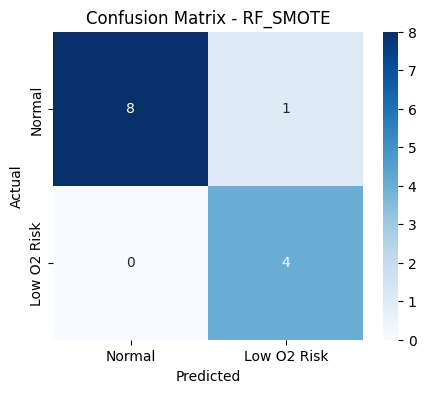


NEXT 3-STEP FUTURE RISK PREDICTION
Model: RF_SMOTE
Probability: 0.692
Threshold: 0.4
Alert: YES
Latitude: 32.736504585218704
Longitude: -120.89696733031674


In [ ]:
!pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

df = pd.read_csv(
    "expanded_ml_ocean_deoxygenation_dataset.csv",
    index_col=0,
    parse_dates=True
)

df.index.name = "Date"

print("Dataset shape:", df.shape)
print("Date range:", df.index.min(), "to", df.index.max())
display(df.head())

o2_threshold = df["O2"].quantile(0.20)

df["Deoxy_event"] = (df["O2"] < o2_threshold).astype(int)

df["Deoxy_next3"] = (
    df["Deoxy_event"]
    .shift(-1)
    .rolling(window=3, min_periods=1)
    .max()
)

df = df.dropna(subset=["Deoxy_next3"])
df["Deoxy_next3"] = df["Deoxy_next3"].astype(int)

print("\nO2 threshold:", o2_threshold)
print("\nTarget distribution:")
print(df["Deoxy_next3"].value_counts())


df["O2_lag1"] = df["O2"].shift(1)
df["O2_lag3"] = df["O2"].shift(3)
df["O2_slope3"] = (df["O2"] - df["O2_lag3"]) / 3

df["OISST_lag1"] = df["OISST"].shift(1)
df["OISST_lag3"] = df["OISST"].shift(3)
df["OISST_slope3"] = (df["OISST"] - df["OISST_lag3"]) / 3

if "Nitrate" in df.columns:
    df["Nitrate_lag1"] = df["Nitrate"].shift(1)
    df["Nitrate_lag3"] = df["Nitrate"].shift(3)
    df["Nitrate_slope3"] = (df["Nitrate"] - df["Nitrate_lag3"]) / 3

if "Phosphate" in df.columns:
    df["Phosphate_lag1"] = df["Phosphate"].shift(1)

if "Silicate" in df.columns:
    df["Silicate_lag1"] = df["Silicate"].shift(1)

if "OISST_anomaly" not in df.columns:
    monthly_clim = df.groupby(df.index.month)["OISST"].mean()
    df["OISST_anomaly"] = df["OISST"] - df.index.month.map(monthly_clim)

df = df.dropna()

candidate_features = [
    "O2",
    "O2_lag1",
    "O2_lag3",
    "O2_slope3",
    "OISST",
    "OISST_lag1",
    "OISST_lag3",
    "OISST_slope3",
    "OISST_anomaly",
    "Nitrate",
    "Nitrate_lag1",
    "Nitrate_slope3",
    "Phosphate",
    "Phosphate_lag1",
    "Silicate",
    "Silicate_lag1",
    "Salinity",
    "OxygenSaturation"
]

features = [c for c in candidate_features if c in df.columns]

X = df[features]
y = df["Deoxy_next3"]

print("\nFinal rows:", len(df))
print("Features used:", len(features))
print(features)

tscv = TimeSeriesSplit(n_splits=3)

models = {
    "LogReg_SMOTE": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42, k_neighbors=3)),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=3000,
            random_state=42
        ))
    ]),

    "RF_SMOTE": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42, k_neighbors=3)),
        ("model", RandomForestClassifier(
            n_estimators=500,
            max_depth=5,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=42
        ))
    ])
}

results = []

for name, model in models.items():
    accs, precs, recs, f1s, aucs = [], [], [], [], []

    print("\nRunning:", name)

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if y_train.value_counts().min() < 4:
            print("Skipping fold: not enough minority samples for SMOTE.")
            continue

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            y_prob = y_pred

        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred, zero_division=0))
        recs.append(recall_score(y_test, y_pred, zero_division=0))
        f1s.append(f1_score(y_test, y_pred, zero_division=0))

        try:
            aucs.append(roc_auc_score(y_test, y_prob))
        except:
            aucs.append(np.nan)

    results.append({
        "Model": name,
        "Accuracy": np.mean(accs),
        "Precision": np.mean(precs),
        "Recall": np.mean(recs),
        "F1": np.mean(f1s),
        "ROC_AUC": np.nanmean(aucs)
    })

results_df = pd.DataFrame(results).sort_values(
    by=["Recall", "F1"],
    ascending=False
)

print("\nMODEL RESULTS")
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

splits = list(tscv.split(X))
train_idx, test_idx = splits[-1]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

best_model.fit(X_train, y_train)

y_prob = best_model.predict_proba(X_test)[:, 1]

threshold_rows = []

for t in np.arange(0.10, 0.91, 0.05):
    y_pred_t = (y_prob >= t).astype(int)

    threshold_rows.append({
        "Threshold": round(t, 2),
        "Accuracy": accuracy_score(y_test, y_pred_t),
        "Precision": precision_score(y_test, y_pred_t, zero_division=0),
        "Recall": recall_score(y_test, y_pred_t, zero_division=0),
        "F1": f1_score(y_test, y_pred_t, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_rows)

print("\nTHRESHOLD TUNING")
display(threshold_df)

best_threshold = threshold_df.sort_values(
    by=["F1", "Recall"],
    ascending=False
).iloc[0]["Threshold"]

print("Best model:", best_model_name)
print("Best threshold:", best_threshold)

final_pred = (y_prob >= best_threshold).astype(int)

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, final_pred, zero_division=0))

cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Low O2 Risk"],
    yticklabels=["Normal", "Low O2 Risk"]
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

best_model.fit(X, y)

last_row = df.iloc[-1]
future_X = pd.DataFrame([last_row[features]])

future_prob = best_model.predict_proba(future_X)[:, 1][0]
future_alert = future_prob >= best_threshold

print("\nNEXT 3-STEP FUTURE RISK PREDICTION")
print("Model:", best_model_name)
print("Probability:", round(future_prob, 3))
print("Threshold:", best_threshold)
print("Alert:", "YES" if future_alert else "NO")

if "Lat" in df.columns:
    print("Latitude:", last_row["Lat"])

if "Lon" in df.columns:
    print("Longitude:", last_row["Lon"])

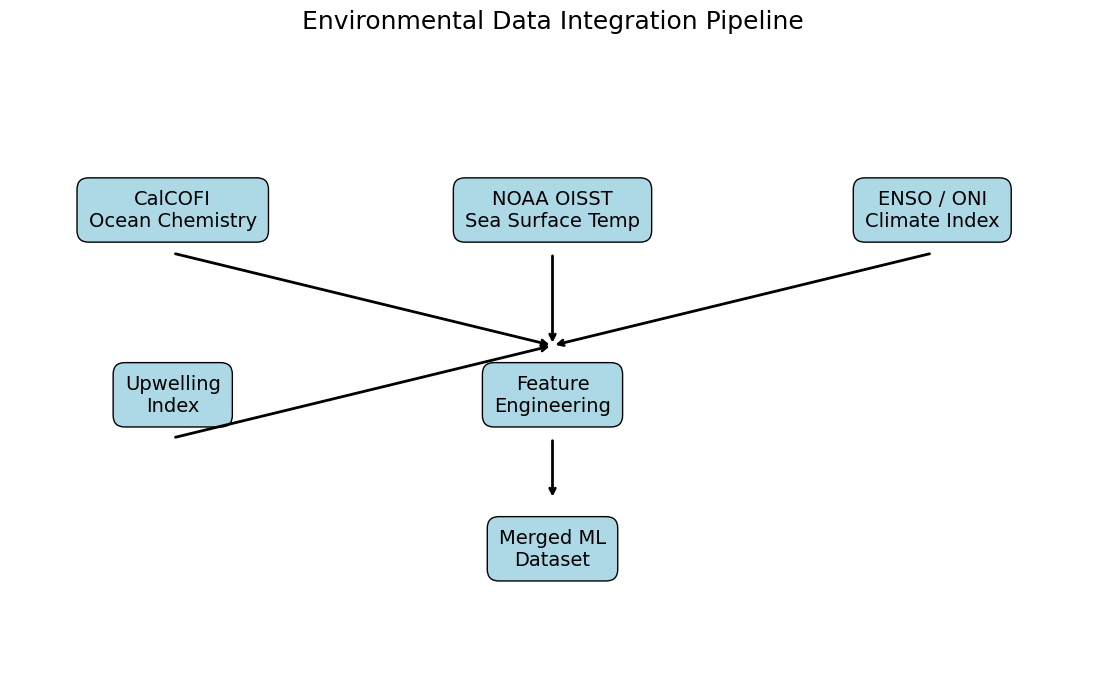

Saved: dataset_merging_architecture.png


In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 8))

ax.axis('off')

# Dataset boxes
datasets = [
    ("CalCOFI\nOcean Chemistry", (0.15, 0.75)),
    ("NOAA OISST\nSea Surface Temp", (0.50, 0.75)),
    ("ENSO / ONI\nClimate Index", (0.85, 0.75)),
    ("Upwelling\nIndex", (0.15, 0.45)),
    ("Feature\nEngineering", (0.50, 0.45)),
    ("Merged ML\nDataset", (0.50, 0.20)),
]

# Draw boxes
for text, (x, y) in datasets:
    ax.text(
        x, y, text,
        ha='center',
        va='center',
        fontsize=14,
        bbox=dict(
            boxstyle="round,pad=0.6",
            edgecolor='black',
            facecolor='lightblue'
        )
    )

# Draw arrows
arrowprops = dict(
    arrowstyle='->',
    lw=2
)

# Arrows into feature engineering
ax.annotate("", xy=(0.50, 0.53), xytext=(0.15, 0.68), arrowprops=arrowprops)
ax.annotate("", xy=(0.50, 0.53), xytext=(0.50, 0.68), arrowprops=arrowprops)
ax.annotate("", xy=(0.50, 0.53), xytext=(0.85, 0.68), arrowprops=arrowprops)
ax.annotate("", xy=(0.50, 0.53), xytext=(0.15, 0.38), arrowprops=arrowprops)

# Arrow to merged dataset
ax.annotate("", xy=(0.50, 0.28), xytext=(0.50, 0.38), arrowprops=arrowprops)

plt.title(
    "Environmental Data Integration Pipeline",
    fontsize=18,
    pad=20
)

plt.savefig(
    "dataset_merging_architecture.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved: dataset_merging_architecture.png")

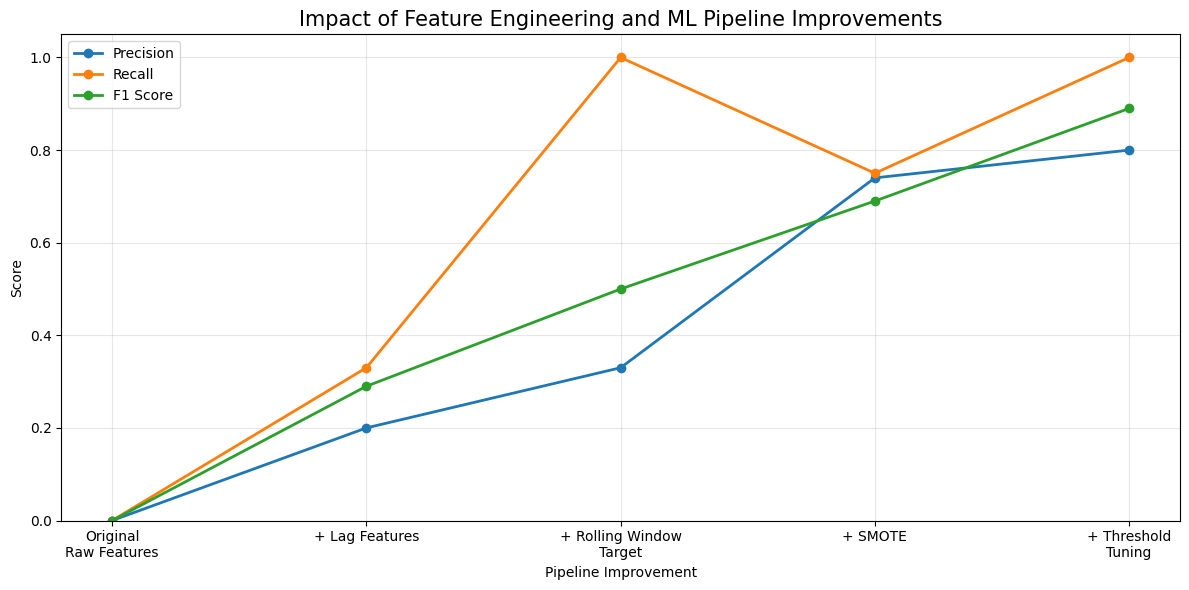

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

performance = pd.DataFrame({
    "Model Version": [
        "Original\nRaw Features",
        "+ Lag Features",
        "+ Rolling Window\nTarget",
        "+ SMOTE",
        "+ Threshold\nTuning"
    ],
    "Precision": [0.00, 0.20, 0.33, 0.74, 0.80],
    "Recall":    [0.00, 0.33, 1.00, 0.75, 1.00],
    "F1 Score":  [0.00, 0.29, 0.50, 0.69, 0.89]
})

plt.figure(figsize=(12, 6))

plt.plot(performance["Model Version"], performance["Precision"], marker="o", linewidth=2, label="Precision")
plt.plot(performance["Model Version"], performance["Recall"], marker="o", linewidth=2, label="Recall")
plt.plot(performance["Model Version"], performance["F1 Score"], marker="o", linewidth=2, label="F1 Score")

plt.title("Impact of Feature Engineering and ML Pipeline Improvements", fontsize=15)
plt.xlabel("Pipeline Improvement")
plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("feature_engineering_model_improvement.png", dpi=300, bbox_inches="tight")
plt.show()

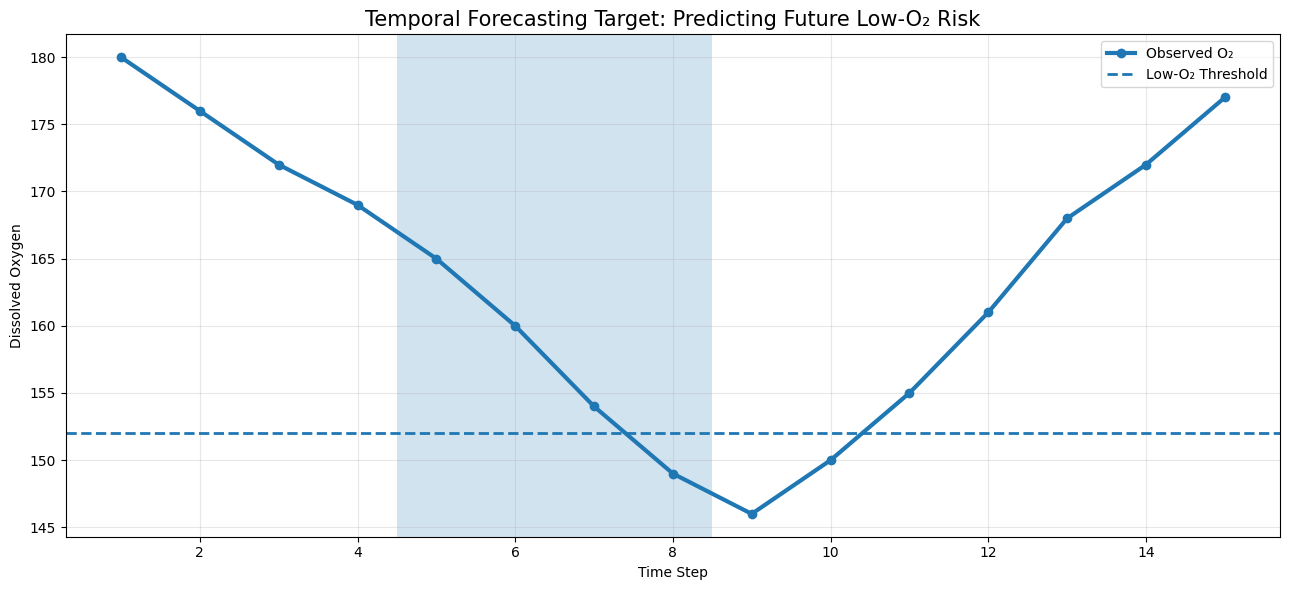

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

time = np.arange(1, 16)

o2 = np.array([
    180, 176, 172, 169, 165,
    160, 154, 149, 146, 150,
    155, 161, 168, 172, 177
])

threshold = 152

future_risk = [0,0,0,0,1,1,1,1,0,0,0,0,0,0,0]

plt.figure(figsize=(13,6))

# Oxygen line
plt.plot(
    time,
    o2,
    marker='o',
    linewidth=3,
    label="Observed O₂"
)

# Threshold line
plt.axhline(
    threshold,
    linestyle='--',
    linewidth=2,
    label="Low-O₂ Threshold"
)

# Highlight future risk window
for i, val in enumerate(future_risk):
    if val == 1:
        plt.axvspan(i+0.5, i+1.5, alpha=0.2)

plt.title(
    "Temporal Forecasting Target: Predicting Future Low-O₂ Risk",
    fontsize=15
)

plt.xlabel("Time Step")
plt.ylabel("Dissolved Oxygen")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "temporal_forecasting_target_visual.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Rows: 54
Features: 18
Target distribution:
Deoxy_next3
0    28
1    26
Name: count, dtype: int64

Logistic Regression

Classification Report:
              precision    recall  f1-score   support

      Normal       0.75      1.00      0.86         9
 Low O2 Risk       1.00      0.25      0.40         4

    accuracy                           0.77        13
   macro avg       0.88      0.62      0.63        13
weighted avg       0.83      0.77      0.72        13



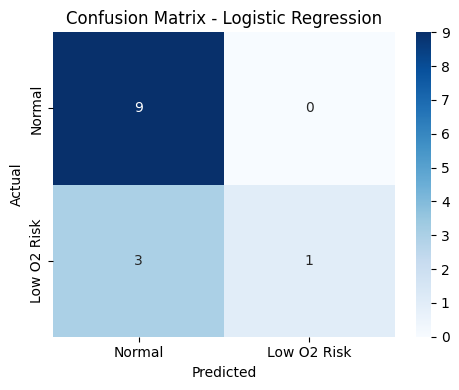


Random Forest

Classification Report:
              precision    recall  f1-score   support

      Normal       0.90      1.00      0.95         9
 Low O2 Risk       1.00      0.75      0.86         4

    accuracy                           0.92        13
   macro avg       0.95      0.88      0.90        13
weighted avg       0.93      0.92      0.92        13



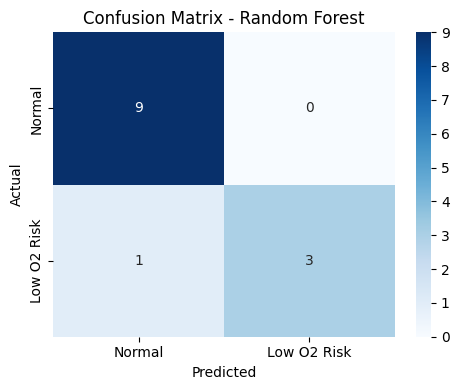


Balanced Random Forest + SMOTE

Classification Report:
              precision    recall  f1-score   support

      Normal       0.75      1.00      0.86         9
 Low O2 Risk       1.00      0.25      0.40         4

    accuracy                           0.77        13
   macro avg       0.88      0.62      0.63        13
weighted avg       0.83      0.77      0.72        13



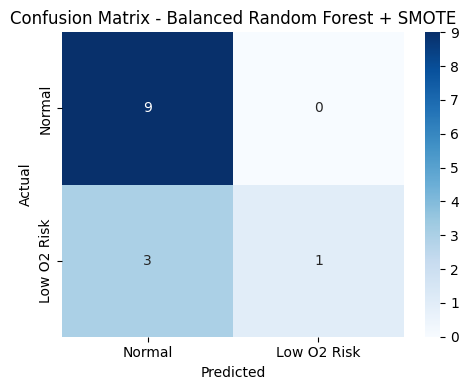


MODEL SUMMARY


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.769231,1.0,0.25,0.400000
1,Random Forest,0.923077,1.0,0.75,0.857143
2,Balanced Random Forest + SMOTE,0.769231,1.0,0.25,0.400000


Saved: model_classification_summary.csv


In [ ]:
# MODEL COMPARISON: REPORTS + CONFUSION MATRICES
# Logistic Regression, Random Forest, Balanced RF + SMOTE

!pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

df = pd.read_csv(
    "expanded_ml_ocean_deoxygenation_dataset.csv",
    index_col=0,
    parse_dates=True
)

df.index.name = "Date"

o2_threshold = df["O2"].quantile(0.20)
df["Deoxy_event"] = (df["O2"] < o2_threshold).astype(int)

df["Deoxy_next3"] = (
    df["Deoxy_event"]
    .shift(-1)
    .rolling(window=3, min_periods=1)
    .max()
)

df = df.dropna(subset=["Deoxy_next3"])
df["Deoxy_next3"] = df["Deoxy_next3"].astype(int)


df["O2_lag1"] = df["O2"].shift(1)
df["O2_lag3"] = df["O2"].shift(3)
df["O2_slope3"] = (df["O2"] - df["O2_lag3"]) / 3

df["OISST_lag1"] = df["OISST"].shift(1)
df["OISST_lag3"] = df["OISST"].shift(3)
df["OISST_slope3"] = (df["OISST"] - df["OISST_lag3"]) / 3

if "OISST_anomaly" not in df.columns:
    monthly_clim = df.groupby(df.index.month)["OISST"].transform("mean")
    df["OISST_anomaly"] = df["OISST"] - monthly_clim

if "Nitrate" in df.columns:
    df["Nitrate_lag1"] = df["Nitrate"].shift(1)
    df["Nitrate_lag3"] = df["Nitrate"].shift(3)
    df["Nitrate_slope3"] = (df["Nitrate"] - df["Nitrate_lag3"]) / 3

if "Phosphate" in df.columns:
    df["Phosphate_lag1"] = df["Phosphate"].shift(1)

if "Silicate" in df.columns:
    df["Silicate_lag1"] = df["Silicate"].shift(1)

df = df.dropna()

candidate_features = [
    "O2",
    "O2_lag1",
    "O2_lag3",
    "O2_slope3",
    "OISST",
    "OISST_lag1",
    "OISST_lag3",
    "OISST_slope3",
    "OISST_anomaly",
    "Nitrate",
    "Nitrate_lag1",
    "Nitrate_slope3",
    "Phosphate",
    "Phosphate_lag1",
    "Silicate",
    "Silicate_lag1",
    "Salinity",
    "OxygenSaturation"
]

features = [c for c in candidate_features if c in df.columns]

X = df[features]
y = df["Deoxy_next3"]

print("Rows:", len(df))
print("Features:", len(features))
print("Target distribution:")
print(y.value_counts())

tscv = TimeSeriesSplit(n_splits=3)
splits = list(tscv.split(X))

train_idx, test_idx = splits[-1]

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

models = {
    "Logistic Regression": ImbPipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=3000,
            random_state=42
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42
    ),

    "Balanced Random Forest + SMOTE": ImbPipeline([
        ("smote", SMOTE(random_state=42, k_neighbors=3)),
        ("model", BalancedRandomForestClassifier(
            n_estimators=300,
            max_depth=5,
            min_samples_leaf=2,
            random_state=42
        ))
    ])
}


summary_rows = []

for name, model in models.items():

    print("\n" + "="*70)
    print(name)
    print("="*70)

    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.predict(X_test)

    y_pred = (y_prob >= 0.50).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    summary_rows.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    })

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Low O2 Risk"],
        zero_division=0
    ))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Normal", "Low O2 Risk"],
        yticklabels=["Normal", "Low O2 Risk"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()

    filename = name.lower().replace(" ", "_").replace("+", "plus") + "_confusion_matrix.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")

    plt.show()


summary_df = pd.DataFrame(summary_rows)

print("\nMODEL SUMMARY")
display(summary_df)

summary_df.to_csv("model_classification_summary.csv", index=False)

print("Saved: model_classification_summary.csv")

,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.307692,0.307692,1.00,0.470588
1,0.15,0.307692,0.307692,1.00,0.470588
2,0.20,0.461538,0.363636,1.00,0.533333
3,0.25,0.769231,0.571429,1.00,0.727273
4,0.30,0.769231,0.571429,1.00,0.727273
5,0.35,0.846154,0.666667,1.00,0.800000
6,0.40,0.923077,0.800000,1.00,0.888889
7,0.45,0.923077,1.000000,0.75,0.857143
8,0.50,0.769231,1.000000,0.25,0.400000
9,0.55,0.769231,1.000000,0.25,0.400000


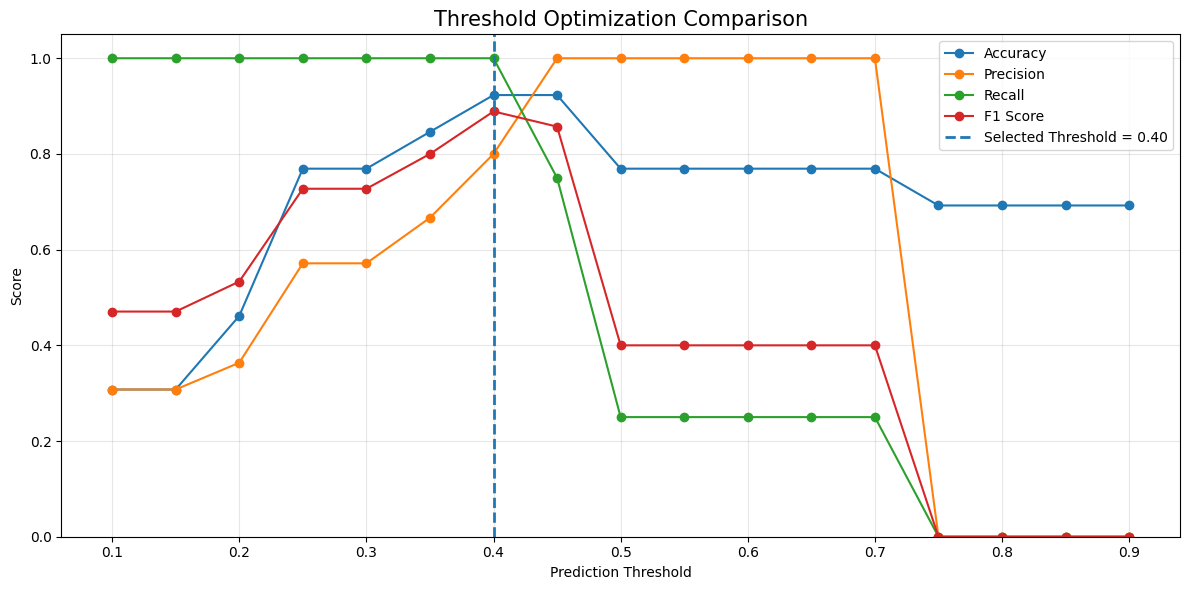

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)


plt.figure(figsize=(12, 6))

plt.plot(threshold_df["Threshold"], threshold_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"], marker="o", label="F1 Score")

plt.axvline(
    x=0.40,
    linestyle="--",
    linewidth=2,
    label="Selected Threshold = 0.40"
)

plt.title("Threshold Optimization Comparison", fontsize=15)
plt.xlabel("Prediction Threshold")
plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("threshold_optimization_comparison.png", dpi=300, bbox_inches="tight")
plt.show()